In [4]:
# pip install h5py

In [7]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform, euclidean
from scipy.stats import chi2_contingency

from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.decomposition import PCA


from tslearn.clustering import TimeSeriesKMeans, KShape
from tslearn.metrics import dtw, cdist_dtw
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ImportError: cannot import name 'set_module' from 'pandas.util._decorators' (c:\Users\douah\projet_ml_unsupervised\venv-ml\Lib\site-packages\pandas\util\_decorators.py)

In [ ]:
HHBLOCK_DIR = "data/hhblock_dataset/hhblock_dataset"

block_files = sorted([f for f in os.listdir(HHBLOCK_DIR) if f.endswith(".csv")])
print(f"{len(block_files)} fichiers block_*.csv trouvés")

dfs = [pd.read_csv(os.path.join(HHBLOCK_DIR, f)) for f in block_files]
df_hh = pd.concat(dfs, ignore_index=True)

df_hh["day"] = pd.to_datetime(df_hh["day"])
hh_cols = [f"hh_{i}" for i in range(48)]

print("Shape :", df_hh.shape)
print("Foyers uniques :", df_hh["LCLid"].nunique())

112 fichiers block_*.csv trouvés
Shape : (3469352, 50)
Foyers uniques : 5560


In [ ]:
df_info = pd.read_csv("data/informations_households.csv")
print(df_info.shape)

(5566, 5)


In [ ]:
PERIOD_START = "2013-01-01"
PERIOD_END = "2013-01-31"

df_jan = df_hh[(df_hh["day"] >= PERIOD_START) & (df_hh["day"] <= PERIOD_END)].copy()

n_jours_attendus = 31

compte_jours_par_foyer = df_jan.groupby("LCLid")["day"].nunique()

foyers_complets = compte_jours_par_foyer[compte_jours_par_foyer == n_jours_attendus].index
foyers_incomplets = compte_jours_par_foyer[compte_jours_par_foyer != n_jours_attendus].index

print(f"Foyers présents sur janvier 2013 : {len(compte_jours_par_foyer)}")
print(f"Foyers COMPLETS (31/31 jours) : {len(foyers_complets)}")
print(f"Foyers EXCLUS (incomplets) : {len(foyers_incomplets)} "
      f"({100*len(foyers_incomplets)/len(compte_jours_par_foyer):.1f}%)")

df_complete = df_jan[df_jan["LCLid"].isin(foyers_complets)].sort_values(["LCLid", "day"]).reset_index(drop=True)

print(f"\nDataset final : {df_complete['LCLid'].nunique()} foyers, {df_complete.shape[0]} lignes")

Foyers présents sur janvier 2013 : 5515
Foyers COMPLETS (31/31 jours) : 4708
Foyers EXCLUS (incomplets) : 807 (14.6%)

Dataset final : 4708 foyers, 145948 lignes


In [ ]:
print("Valeurs manquantes (NaN) :", df_complete[hh_cols].isna().sum().sum())
print("Valeurs négatives :", (df_complete[hh_cols] < 0).sum().sum())

Valeurs manquantes (NaN) : 0
Valeurs négatives : 0


In [ ]:
mean_curves = df_complete.groupby("LCLid")[hh_cols].mean()

print(f"Table des journées moyennes : {mean_curves.shape[0]} foyers x {mean_curves.shape[1]} pas de 30 min")
mean_curves.head()

Table des journées moyennes : 4708 foyers x 48 pas de 30 min


,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
LCLid,,,,,,,,,,,,,,,,,,,,,
MAC000002,0.230097,0.239194,0.233871,0.222677,0.201871,0.176774,0.146806,0.121968,0.113323,0.109161,...,0.329516,0.392484,0.886000,0.390516,0.293258,0.326387,0.339839,0.354000,0.297935,0.269419
MAC000003,2.633161,2.574387,2.490645,2.035226,1.926742,1.908548,1.969677,1.895677,2.033581,1.846355,...,0.200258,0.164226,0.184226,0.184000,0.176871,0.159258,0.164065,0.192129,0.182581,0.143516
MAC000004,0.027742,0.044258,0.041581,0.018290,0.037581,0.049032,0.034194,0.050484,0.017581,0.022194,...,0.035032,0.041226,0.048419,0.032968,0.024677,0.049161,0.050032,0.042323,0.023194,0.041774
MAC000005,0.049516,0.036774,0.031710,0.030194,0.030355,0.030516,0.030516,0.030290,0.030355,0.029806,...,0.218000,0.192290,0.153903,0.131968,0.149000,0.188161,0.201677,0.189032,0.125968,0.085677
MAC000006,0.033065,0.029903,0.025581,0.021000,0.021323,0.021613,0.020032,0.021839,0.020548,0.022355,...,0.098516,0.095613,0.088484,0.094290,0.073839,0.056839,0.050677,0.055161,0.038742,0.045323


In [ ]:
X_raw = mean_curves.values[:, :, np.newaxis]

print("Shape avant normalisation :", X_raw.shape)

Shape avant normalisation : (4708, 48, 1)


In [ ]:
X_norm = TimeSeriesScalerMeanVariance().fit_transform(X_raw)

nb_nan = np.isnan(X_norm).sum()
print(f"Valeurs NaN après normalisation : {nb_nan}")

Valeurs NaN après normalisation : 0


Exemple d'illustration entre la distance Euclidiean et DTW

In [ ]:
from scipy.spatial.distance import euclidean as euclidean_dist
from tslearn.metrics import dtw

t = np.arange(48)

courbe_a = 0.15 + 0.6 * np.exp(-((t - 38) ** 2) / (2 * 3 ** 2))   
courbe_b = 0.15 + 0.6 * np.exp(-((t - 41) ** 2) / (2 * 3 ** 2)) 

d_euclidean = euclidean_dist(courbe_a, courbe_b)

d_dtw = dtw(courbe_a, courbe_b)

print(f"Distance EUCLIDIENNE : {d_euclidean:.4f}")
print(f"Distance DTW         : {d_dtw:.4f}")
print(f"\n→ La distance euclidienne pénalise fortement le simple décalage horaire,")
print(f"   alors que le DTW reconnaît qu'il s'agit quasiment de la même forme de courbe.")

Distance EUCLIDIENNE : 0.9193
Distance DTW         : 0.1068

→ La distance euclidienne pénalise fortement le simple décalage horaire,
   alors que le DTW reconnaît qu'il s'agit quasiment de la même forme de courbe.


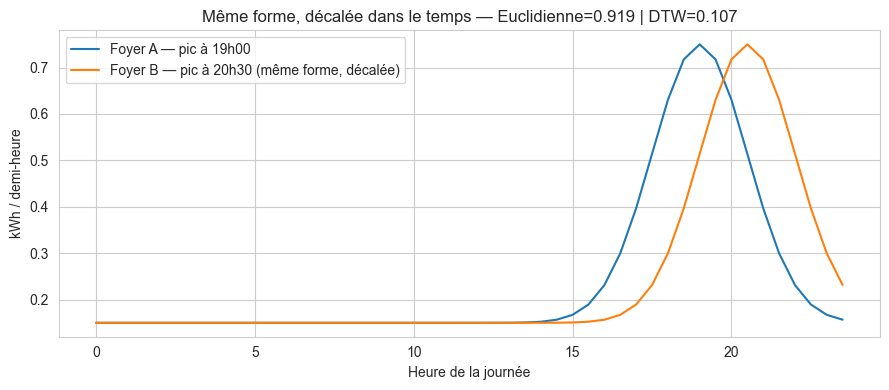

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(t / 2, courbe_a, label="Foyer A — pic à 19h00")
plt.plot(t / 2, courbe_b, label="Foyer B — pic à 20h30 (même forme, décalée)")
plt.xlabel("Heure de la journée")
plt.ylabel("kWh / demi-heure")
plt.title(f"Même forme, décalée dans le temps — Euclidienne={d_euclidean:.3f} | DTW={d_dtw:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
N_SAMPLE = 800  

rng = np.random.default_rng(RANDOM_STATE)

if X_norm.shape[0] > N_SAMPLE:
    sample_idx = rng.choice(X_norm.shape[0], size=N_SAMPLE, replace=False)
else:
    sample_idx = np.arange(X_norm.shape[0])

X_sample = X_norm[sample_idx]
ids_sample = mean_curves.index.to_numpy()[sample_idx]

print(f"Échantillon retenu pour le clustering DTW : {X_sample.shape[0]} foyers")

Échantillon retenu pour le clustering DTW : 800 foyers


In [ ]:
t0 = time.time()
D_dtw = cdist_dtw(X_sample)
elapsed = time.time() - t0

print(f"Matrice de distances DTW calculée : {D_dtw.shape} en {elapsed:.1f} secondes")

Matrice de distances DTW calculée : (800, 800) en 24.5 secondes


In [ ]:
K_RANGE = range(2, 6)
inerties = []
silhouettes = []

for k in K_RANGE:
   
    km_k = TimeSeriesKMeans(n_clusters=k, metric="dtw", random_state=RANDOM_STATE,
                             n_init=3, max_iter=20, n_jobs=-1)
    labels_k = km_k.fit_predict(X_sample)

    inerties.append(km_k.inertia_)

   
    sil = silhouette_score(D_dtw, labels_k, metric="precomputed")
    silhouettes.append(sil)

    print(f"K={k} | inertie={km_k.inertia_:.2f} | silhouette (DTW)={sil:.3f}")

K=2 | inertie=6.34 | silhouette (DTW)=0.266
K=3 | inertie=5.72 | silhouette (DTW)=0.212
K=4 | inertie=5.32 | silhouette (DTW)=0.136
K=5 | inertie=5.07 | silhouette (DTW)=0.120


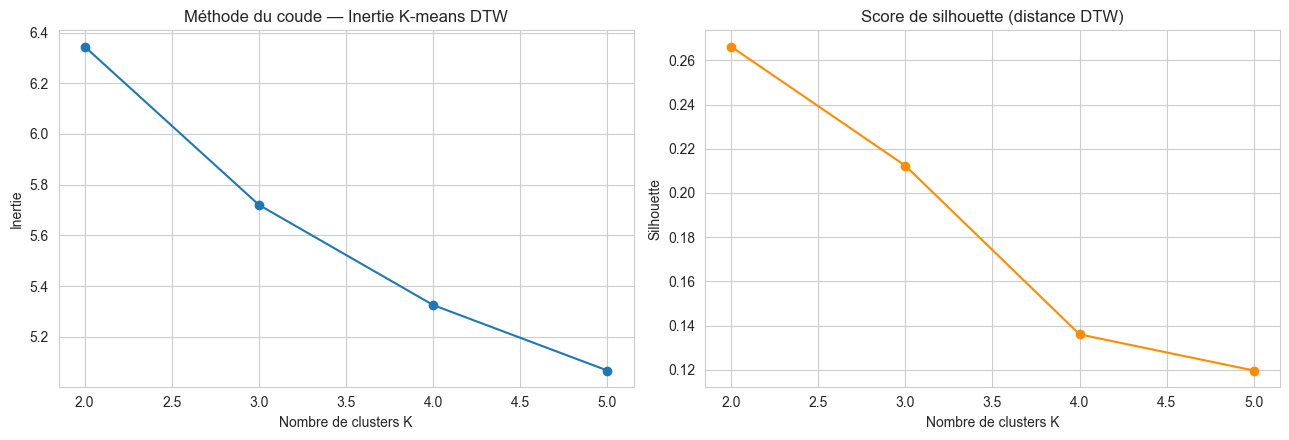

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(K_RANGE), inerties, marker="o")
axes[0].set_title("Méthode du coude — Inertie K-means DTW")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_ylabel("Inertie")

axes[1].plot(list(K_RANGE), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Score de silhouette (distance DTW)")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

On retient **K=2**, valeur pour laquelle la silhouette DTW est maximale (0.266) et décroît ensuite de façon monotone (0.212 à K=3, 0.136 à K=4), cohérent avec le résultat de l'Approche B.

In [ ]:
K_FINAL = 2

km_final = TimeSeriesKMeans(n_clusters=K_FINAL, metric="dtw", random_state=RANDOM_STATE,
                             n_init=5, max_iter=30, n_jobs=-1)
labels_kmeans_dtw = km_final.fit_predict(X_sample)

print("Répartition des foyers par cluster (K-means DTW) :")
print(pd.Series(labels_kmeans_dtw).value_counts().sort_index())

Répartition des foyers par cluster (K-means DTW) :
0    564
1    236
Name: count, dtype: int64


In [ ]:
# CAH sur la matrice de distances DTW déjà calculée (D_dtw)
# squareform convertit la matrice carrée en format condensé attendu par linkage()
condensed_D = squareform(D_dtw, checks=False)

# method="average" recommandé quand on fournit une matrice de distances précalculée
# (contrairement à "ward" qui suppose des coordonnées euclidiennes, pas juste des distances)
Z = linkage(condensed_D, method="average")

labels_cah_dtw = fcluster(Z, t=K_FINAL, criterion="maxclust") - 1

print("Répartition des foyers par cluster (CAH sur DTW) :")
print(pd.Series(labels_cah_dtw).value_counts().sort_index())

Répartition des foyers par cluster (CAH sur DTW) :
0    790
1     10
Name: count, dtype: int64


In [ ]:
# Comparaison K-means DTW vs CAH DTW
ari_kmeans_cah_dtw = adjusted_rand_score(labels_kmeans_dtw, labels_cah_dtw)
sil_kmeans_dtw = silhouette_score(D_dtw, labels_kmeans_dtw, metric="precomputed")
sil_cah_dtw = silhouette_score(D_dtw, labels_cah_dtw, metric="precomputed")

print(f"ARI K-means DTW vs CAH DTW : {ari_kmeans_cah_dtw:.3f}")
print(f"Silhouette K-means DTW : {sil_kmeans_dtw:.3f} | Silhouette CAH DTW : {sil_cah_dtw:.3f}")

ARI K-means DTW vs CAH DTW : 0.035
Silhouette K-means DTW : 0.266 | Silhouette CAH DTW : 0.575


In [ ]:
from tslearn.clustering import KShape

# KShape utilise la distance SBD (Shape-Based Distance), basée sur la corrélation
# croisée normalisée — comme le DTW, elle est invariante aux décalages temporels,
# mais avec un calcul beaucoup plus rapide
kshape_final = KShape(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=5)
labels_kshape = kshape_final.fit_predict(X_sample)

print("Répartition des foyers par cluster (K-Shape) :")
print(pd.Series(labels_kshape).value_counts().sort_index())

Répartition des foyers par cluster (K-Shape) :
0    502
1    298
Name: count, dtype: int64


In [ ]:
# Comparaison ARI avec K-means DTW et CAH DTW
ari_kmeans_kshape = adjusted_rand_score(labels_kmeans_dtw, labels_kshape)
ari_cah_kshape = adjusted_rand_score(labels_cah_dtw, labels_kshape)

# Silhouette calculée avec la matrice DTW précalculée (cohérent puisque K-Shape,
# comme K-means-DTW et CAH, respecte la structure temporelle)
sil_kshape = silhouette_score(D_dtw, labels_kshape, metric="precomputed")

print(f"ARI K-means DTW vs K-Shape : {ari_kmeans_kshape:.3f}")
print(f"ARI CAH DTW vs K-Shape     : {ari_cah_kshape:.3f}")
print(f"\nSilhouette K-Shape (DTW)   : {sil_kshape:.3f}")

ARI K-means DTW vs K-Shape : 0.011
ARI CAH DTW vs K-Shape     : 0.015

Silhouette K-Shape (DTW)   : 0.105


In [ ]:
# Tableau récapitulatif final des 3 méthodes de l'Approche A (toutes basées sur la forme temporelle)
comparatif_A = pd.DataFrame({
    "Méthode": ["K-means (DTW)", "CAH (DTW)", "K-Shape"],
    "N clusters": [K_FINAL, K_FINAL, K_FINAL],
    "Silhouette (DTW)": [sil_kmeans_dtw, sil_cah_dtw, sil_kshape],
})
print(comparatif_A)

         Méthode  N clusters  Silhouette (DTW)
0  K-means (DTW)           2          0.266194
1      CAH (DTW)           2          0.574649
2        K-Shape           2          0.104582


In [ ]:
from sklearn.decomposition import PCA

# On aplatit X_sample (n_foyers, 48, 1) en (n_foyers, 48) pour l'ACP
# (l'ACP ne comprend pas le format 3D de tslearn, elle attend des vecteurs classiques)
X_sample_flat = X_sample.reshape(X_sample.shape[0], -1)

pca_A = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_A = pca_A.fit_transform(X_sample_flat)

print("Variance expliquée PC1:", pca_A.explained_variance_ratio_[0])
print("Variance expliquée PC2:", pca_A.explained_variance_ratio_[1])
print("Variance totale:", pca_A.explained_variance_ratio_.sum())

Variance expliquée PC1: 0.23352037373711312
Variance expliquée PC2: 0.1537062183892405
Variance totale: 0.38722659212635363


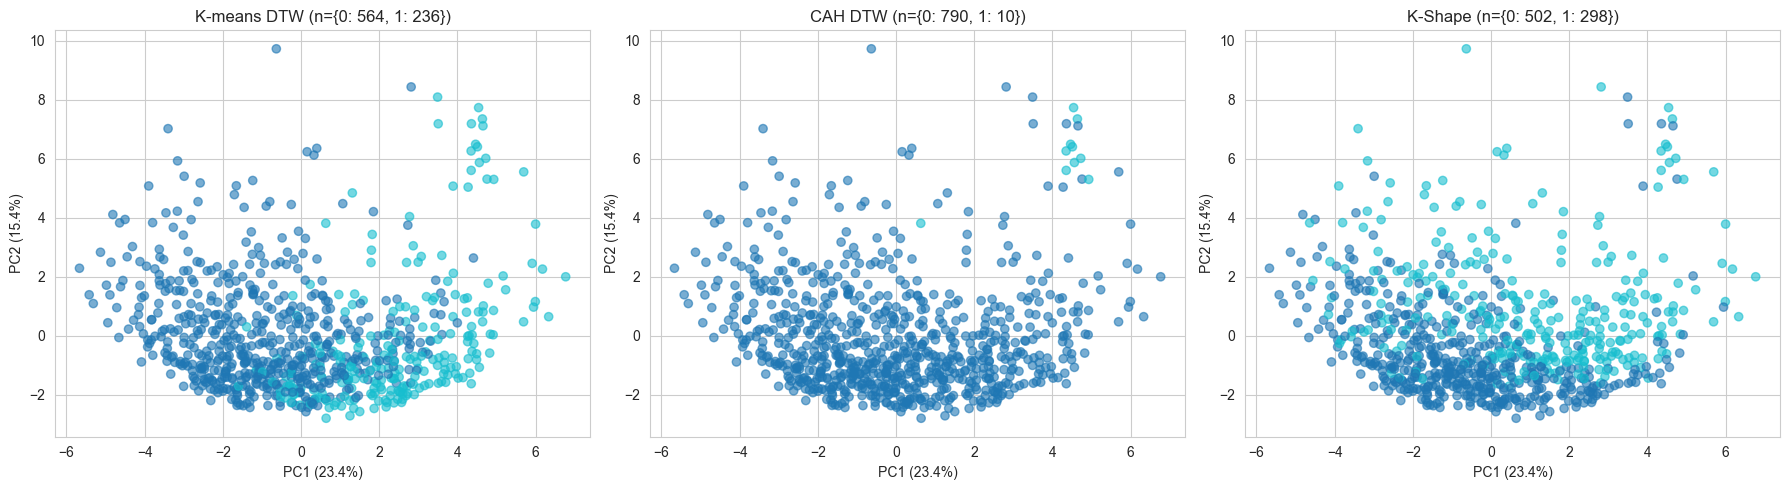

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-means DTW
axes[0].scatter(X_pca_A[:, 0], X_pca_A[:, 1], c=labels_kmeans_dtw, cmap="tab10", alpha=0.6)
axes[0].set_title(f"K-means DTW (n={pd.Series(labels_kmeans_dtw).value_counts().to_dict()})")

# CAH DTW
axes[1].scatter(X_pca_A[:, 0], X_pca_A[:, 1], c=labels_cah_dtw, cmap="tab10", alpha=0.6)
axes[1].set_title(f"CAH DTW (n={pd.Series(labels_cah_dtw).value_counts().to_dict()})")

# K-Shape
axes[2].scatter(X_pca_A[:, 0], X_pca_A[:, 1], c=labels_kshape, cmap="tab10", alpha=0.6)
axes[2].set_title(f"K-Shape (n={pd.Series(labels_kshape).value_counts().to_dict()})")

for ax in axes:
    ax.set_xlabel(f"PC1 ({pca_A.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca_A.explained_variance_ratio_[1]*100:.1f}%)")

plt.tight_layout()
plt.show()

## Confirmation visuelle (ACP) — Approche A

La projection ACP confirme l'interprétation numérique : la CAH isole les 10 foyers les plus atypiques (points isolés en haut du nuage, PC2>6) sans produire de vraie typologie sur le reste des foyers, ce qui explique sa silhouette artificiellement élevée. K-means DTW et K-Shape, en revanche, découpent tous deux le nuage principal en deux zones globalement équilibrées, mais selon des lignes de séparation différentes (ARI=0.011) — signe que le signal DTW sur la journée moyenne est plus ambigu ou multi-directionnel que celui trouvé en Approche B, plutôt qu'une structure binaire nette et unique.


## Méthode retenue — K-means DTW

Parmi les méthodes testées pour l'Approche A (K-means DTW, CAH sur matrice DTW, K-Shape), la convergence entre elles est très faible (ARI entre 0.011 et 0.035). La CAH affiche une silhouette élevée (0.575) mais trompeuse : la projection ACP montre qu'elle isole seulement 10 foyers très atypiques plutôt que de révéler une vraie typologie (790 vs 10). K-Shape produit une répartition plus équilibrée (502/298) mais découpe le nuage de foyers selon un axe différent de K-means, sans qu'aucun élément ne permette pour l'instant de privilégier l'un ou l'autre.

**K-means DTW est retenue comme méthode principale** : elle offre la répartition la plus équilibrée et interprétable a priori (564/236), avec une silhouette DTW cohérente (0.266) sur l'ensemble du nuage plutôt que sur une poignée de points isolés. CAH et K-Shape restent mobilisées comme méthodes de comparaison pour la suite (critère de convergence), mais les courbes de charge et le portrait-robot qui suivent sont construits sur les clusters K-means DTW.

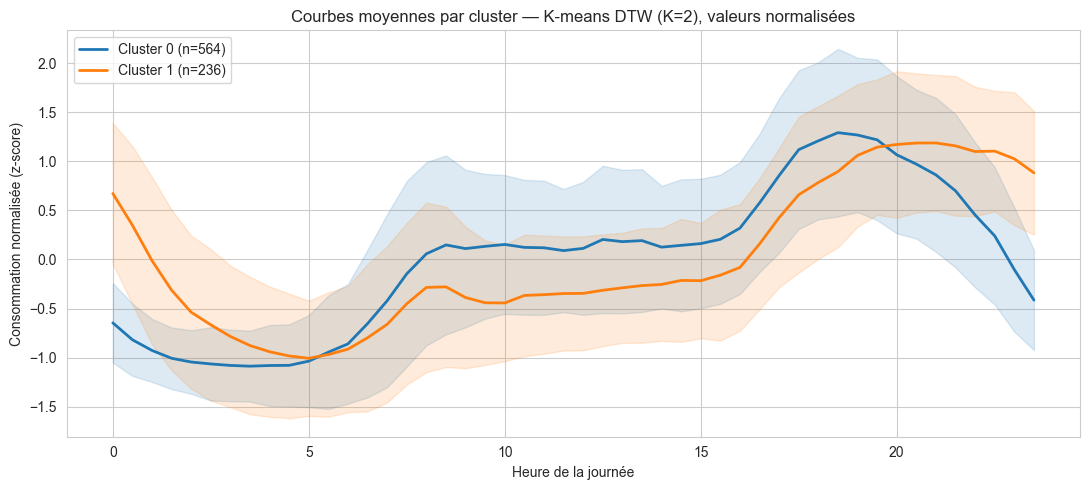

In [ ]:
heures = np.arange(48) / 2
palette = ["#1f77b4", "#ff7f0e"]

fig, ax = plt.subplots(figsize=(11, 5))

for c in range(K_FINAL):
    mask = labels_kmeans_dtw == c

    # Courbes NORMALISÉES (celles utilisées pour le clustering DTW)
    courbes_cluster = X_sample[mask, :, 0]
    moyenne = courbes_cluster.mean(axis=0)
    ecart_type = courbes_cluster.std(axis=0)

    ax.plot(heures, moyenne, label=f"Cluster {c} (n={mask.sum()})", color=palette[c], linewidth=2)
    ax.fill_between(heures, moyenne - ecart_type, moyenne + ecart_type,
                     color=palette[c], alpha=0.15)

ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Consommation normalisée (z-score)")
ax.set_title("Courbes moyennes par cluster — K-means DTW (K=2), valeurs normalisées")
ax.legend()
plt.tight_layout()
plt.show()

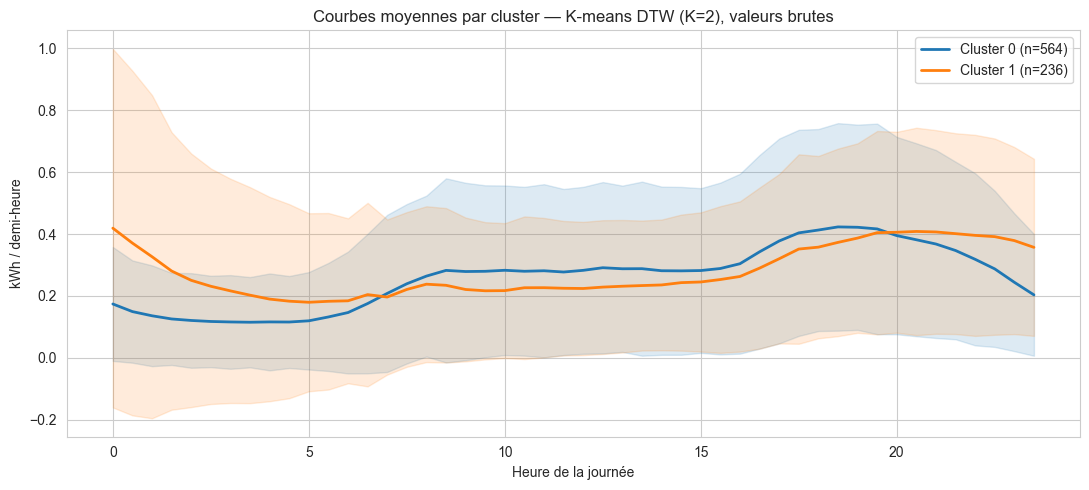

In [ ]:
# Même chose en valeurs BRUTES (kWh) pour l'interprétation métier
fig, ax = plt.subplots(figsize=(11, 5))

# mean_curves contient les journées moyennes brutes, dans l'ordre de mean_curves.index
# ids_sample donne les LCLid correspondant à chaque ligne de X_sample, dans le même ordre
courbes_brutes_sample = mean_curves.loc[ids_sample].values

for c in range(K_FINAL):
    mask = labels_kmeans_dtw == c
    courbes_cluster_brutes = courbes_brutes_sample[mask]

    moyenne_brute = courbes_cluster_brutes.mean(axis=0)
    ecart_type_brute = courbes_cluster_brutes.std(axis=0)

    ax.plot(heures, moyenne_brute, label=f"Cluster {c} (n={mask.sum()})", color=palette[c], linewidth=2)
    ax.fill_between(heures, moyenne_brute - ecart_type_brute, moyenne_brute + ecart_type_brute,
                     color=palette[c], alpha=0.15)

ax.set_xlabel("Heure de la journée")
ax.set_ylabel("kWh / demi-heure")
ax.set_title("Courbes moyennes par cluster — K-means DTW (K=2), valeurs brutes")
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

K-means DTW (Approche A) retrouve une distinction très similaire à celle de l'Approche B, malgré une méthodologie différente (comparaison de formes via DTW vs vecteurs de features euclidiens) : un cluster "nocturne/continu" (n=236, conso élevée la nuit, pic tardif ~20-21h) et un cluster "jour actif" (n=564, contraste jour/nuit marqué, pic précoce ~19h, chute rapide en soirée). Cette convergence inter-approches, malgré le désaccord entre les 3 méthodes internes à l'Approche A, renforce la robustesse de cette typologie binaire comme caractéristique réelle des foyers londoniens.

In [ ]:
portrait_A = []
for c in range(K_FINAL):
    mask = labels_kmeans_dtw == c
    courbes_brutes = courbes_brutes_sample[mask]

    volume_moyen = courbes_brutes.sum(axis=1).mean()
    heure_pointe = np.argmax(courbes_brutes.mean(axis=0)) / 2

    indices = np.arange(48)
    masque_jour = (indices >= 14) & (indices < 44)  # 7h-22h
    conso_jour = courbes_brutes[:, masque_jour].mean()
    conso_nuit = courbes_brutes[:, ~masque_jour].mean()

    portrait_A.append({
        "Cluster": c,
        "N_foyers": int(mask.sum()),
        "Volume_moyen_kWh_jour": round(volume_moyen, 2),
        "Heure_de_pointe": f"{heure_pointe:.1f}h",
        "Conso_jour_moyenne": round(conso_jour, 3),
        "Conso_nuit_moyenne": round(conso_nuit, 3),
        "Ratio_jour_nuit": round(conso_jour / conso_nuit, 2),
    })

portrait_A_df = pd.DataFrame(portrait_A)
print(portrait_A_df)

   Cluster  N_foyers  Volume_moyen_kWh_jour Heure_de_pointe  \
0        0       564                  12.47           18.5h   
1        1       236                  13.43            0.0h   

   Conso_jour_moyenne  Conso_nuit_moyenne  Ratio_jour_nuit  
0               0.318               0.162             1.97  
1               0.283               0.275             1.03  


In [ ]:
# Correction : on exclut la toute début/fin de nuit (minuit) pour ne chercher
# le pic que dans une plage horaire réaliste (ex: 12h-24h, indices 24 à 47)
for i, c in enumerate(range(K_FINAL)):
    mask = labels_kmeans_dtw == c
    courbe_moyenne_c = courbes_brutes_sample[mask].mean(axis=0)

    # On cherche le maximum uniquement entre 12h et 23h30 (indices 24 à 47)
    indice_pointe = 24 + np.argmax(courbe_moyenne_c[24:])
    heure_pointe_corrigee = indice_pointe / 2

    print(f"Cluster {c} : heure de pointe (corrigée) = {heure_pointe_corrigee}h")

NameError: name 'K_FINAL' is not defined